In [29]:
import tensorflow as tf
import numpy as np
import  warnings
warnings.filterwarnings('ignore')
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


In [43]:
model = Sequential([
    LSTM(4, input_shape=(5, 1)),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer = Adam(), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 4)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101 (404.00 B)

 Trainable params: 101 (404.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
y_train = np.array([
    0,
    0,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1
])


In [25]:
X_train = np.array([

    [[0.1], [0.2], [0.3], [0.4], [0.5]],

    [[0.5], [0.4], [0.3], [0.2], [0.1]],

    [[0.2], [0.3], [0.4], [0.5], [0.6]],

    [[0.9], [0.8], [0.7], [0.6], [0.5]],

    [[0.1], [0.1], [0.2], [0.2], [0.3]],

    [[0.8], [0.9], [0.8], [0.9], [0.8]],

    [[0.3], [0.4], [0.3], [0.4], [0.3]],

    [[0.7], [0.8], [0.7], [0.8], [0.7]],

    [[0.2], [0.1], [0.2], [0.1], [0.2]],

    [[0.9], [0.9], [0.8], [0.8], [0.9]]

])

In [54]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [55]:
history = model.fit(X_train, y_train, epochs=100, verbose=1, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 1.0000 - loss: 0.4942 - val_accuracy: 1.0000 - val_loss: 0.4199
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 1.0000 - loss: 0.4912 - val_accuracy: 1.0000 - val_loss: 0.4165
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 1.0000 - loss: 0.4881 - val_accuracy: 1.0000 - val_loss: 0.4131
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 1.0000 - loss: 0.4850 - val_accuracy: 1.0000 - val_loss: 0.4097


In [56]:
X_test = np.array([[0.5], [0.7], [0.1], [0.9], [1.0]])

pred = model.predict(X_test)

if pred[0][0] >= 0.5:
    print("Class 1")
else:
    print("Class 2")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
Class 2


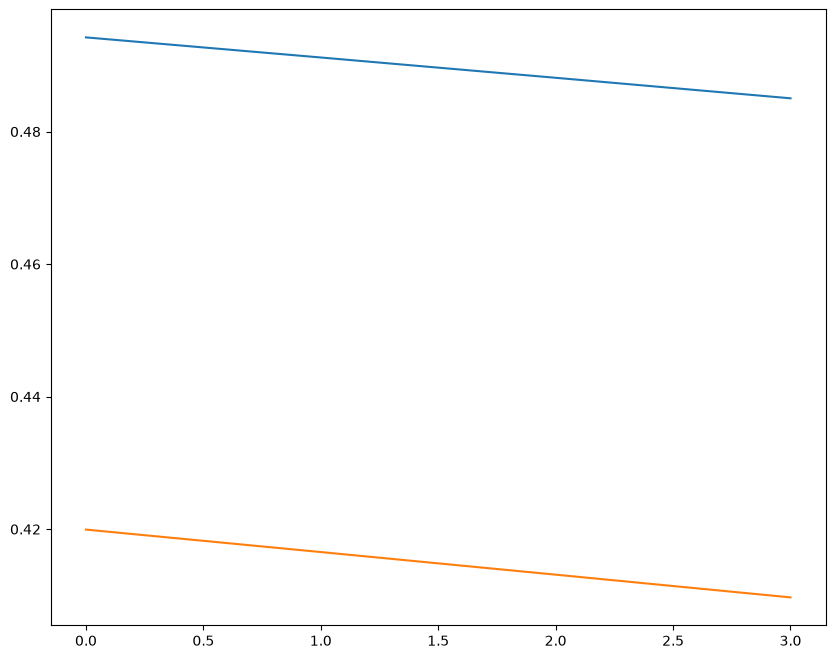

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.plot(history.history['loss'], label="Training Accuracy")
plt.plot(history.history['val_loss'], label="Training Loss")
plt.show()

